# Spectral density as a function of $U_{IB}$ #

In [294]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import matplotlib
import h5py
import numpy as np
import class_utils as class_utils
from class_grid import Grid
from class_params import Params
from class_groundstate import groundstate
from class_excitations import excitations
from class_vertices import vertices
from class_perturbation import perturbative
from class_self_energy import Self_Energy
from class_io import IO
from class_plotting import plot2D, plot_cns, plot_omega0
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker


### For different $U_{IB}$ values

In [198]:
config_path = "config.yml" 

dJU = 0.2 # which hopping value are we fixing to
muU = np.sqrt(2) - 1 # which chemical potential we are fixing to

output_dir = class_utils.create_output_dir()
config = class_utils.read_config(config_path)

Lx = config["grid"]["Lx"]
Ly = config["grid"]["Ly"]
cutoff = config["physics"]["cutoff"]
N = config["physics"]["N"]
M = Lx * Ly

grid = Grid(Lx, Ly)

num_en = 250 #150 # 100
num_UIB = 150 # 100
en_vector = np.linspace(-2,1,num_en)
UIBs = np.linspace(-1.5, 1.5, num_UIB)

In [ ]:
### RUN THIS BLOCK IF LOADING FROM A FILE. ###

input("confirm data is to be loaded.")

filename = f'../data/Spectral_Line_UIB_Scan/dJU_{dJU}_Mu_{muU:.2f}_M_{M}_N_{N}_num_en_{len(en_vector)}_num_UIB_{len(UIBs)}_extended.hdf5'
with h5py.File(filename, 'r') as f:
    UIBs = f['UIBs'][:]
    en_vector = f['en_vector'][:]
    omega0s = f['omega0s'][:]
    omega1s = f['omega1s'][:]
    omega2s = f['omega2s'][:]

    T11 = []
    T12 = []
    T21 = []
    T22 = []
    T22_F = []
    SE_SI = []

    for count, UIB in enumerate(UIBs):
        group = f[f'UIB_{UIB}']
        T11.append(group['T11'][:])
        T12.append(group['T12'][:])
        T21.append(group['T21'][:])
        T22.append(group['T22'][:])
        T22_F.append(group['T22_SE'][:])
        SE_SI.append(group['SE_SI'][:])

In [295]:
# run this block if you are making the data for the first time

input("confirm that you would like to make the data for the first time")

omega0s = np.zeros(len(UIBs))
omega1s = np.zeros(len(UIBs))
omega2s = np.zeros(len(UIBs))

SE = np.zeros((7, len(en_vector)), dtype=np.complex128)  #7 rows for each contribution, num_en columns 
SE_NSC = SE

#V:  Add poles to this plot!!!
T11 = np.zeros((len(UIBs), len(en_vector)), dtype=np.complex128)
T12 = np.zeros((len(UIBs), len(en_vector)), dtype=np.complex128)
T21 = np.zeros((len(UIBs), len(en_vector)), dtype=np.complex128)
T22 = np.zeros((len(UIBs), len(en_vector)), dtype=np.complex128)
T22_F = np.zeros((len(UIBs), len(en_vector)), dtype=np.complex128)
SE_SI = np.zeros((len(UIBs), len(en_vector)), dtype=np.complex128)

for count, UIB in enumerate(UIBs):
    params = Params(N, dJU, muU, UIB, cutoff)
    print(count,UIB)
    gs = groundstate(params)
    cns = gs.cns()
    n0 = gs.n0(cns)
    psi0 = gs.psi0(cns)
    exc = excitations(grid, params, gs, cns)
    uks, vks, omegaklambda = exc.calculate_matrices()
    verts = vertices(grid, gs, uks, vks, cns, n0)
    pert = perturbative(grid, params, verts, omegaklambda)
    Pert_Energy = pert.perturbative_energy(n0)
    omega0s[count] = Pert_Energy[0]
    omega1s[count] = Pert_Energy[1]
    omega2s[count] = Pert_Energy[2]

    for epol_ind in range(len(en_vector)):
        # Non-self consistent
        Epol_NSC = en_vector[epol_ind] 
        self_energy = Self_Energy(Epol_NSC, grid, params, verts, omegaklambda)
        # output_NSC = self_energy.calculate_self_energy()
        output_NSC = self_energy.calculate_self_energy_nsc()
        #SE_NSC[:, epol_ind] = output_NSC
        # Self-consistent (1 iteration).  Note:  this can be sped up by making class for SE w/out phonon loop for NSC calc.  
        # Epol_SC = en_vector[epol_ind] - (SE_NSC[1, epol_ind] + SE_NSC[2, epol_ind] + SE_NSC[3, epol_ind] + SE_NSC[4, epol_ind] ) # scat of mf density only
        Epol_SC = en_vector[epol_ind] - output_NSC
        self_energy = Self_Energy(Epol_SC, grid, params, verts, omegaklambda)
        output_SC = self_energy.calculate_self_energy()
        SE[:, epol_ind] = output_SC
    #The zeroth element is the full self energy minus w, used for finding the zero crossings.
    T11[count, :] = SE[1, :]
    T12[count, :] = SE[2, :]
    T21[count, :] = SE[3, :]
    T22[count, :] = SE[4, :]
    T22_F[count, :] = SE[5, :]
    SE_SI[count, :] = SE[6, :]

0 -1.5
1 -1.4696969696969697
2 -1.4393939393939394
3 -1.4090909090909092
4 -1.378787878787879
5 -1.3484848484848484
6 -1.3181818181818181
7 -1.2878787878787878
8 -1.2575757575757576
9 -1.2272727272727273
10 -1.196969696969697
11 -1.1666666666666665
12 -1.1363636363636362
13 -1.106060606060606
14 -1.0757575757575757
15 -1.0454545454545454
16 -1.0151515151515151
17 -0.9848484848484849
18 -0.9545454545454546
19 -0.9242424242424242
20 -0.8939393939393939
21 -0.8636363636363636
22 -0.8333333333333333
23 -0.803030303030303
24 -0.7727272727272727
25 -0.7424242424242424
26 -0.7121212121212122
27 -0.6818181818181818
28 -0.6515151515151515
29 -0.6212121212121212
30 -0.5909090909090908
31 -0.5606060606060606
32 -0.5303030303030303
33 -0.5
34 -0.4696969696969697
35 -0.43939393939393945
36 -0.40909090909090917
37 -0.3787878787878787
38 -0.3484848484848484
39 -0.3181818181818181
40 -0.28787878787878785
41 -0.25757575757575757
42 -0.2272727272727273
43 -0.19696969696969702
44 -0.16666666666666652
45 

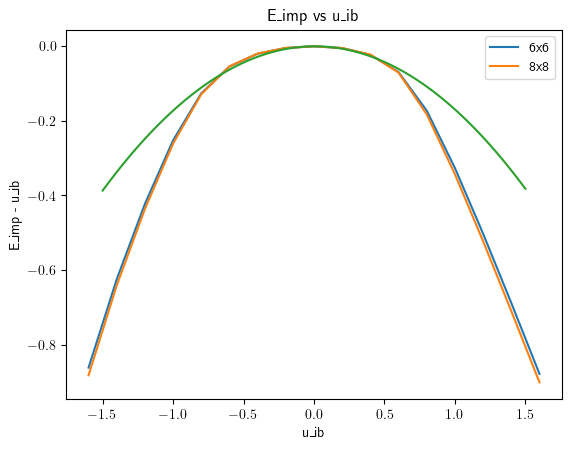

In [602]:
import csv
import matplotlib.pyplot as plt

with open('matija_data/6by6.csv', mode='r') as infile:
    reader = csv.DictReader(infile)
    data = {fieldname: [] for fieldname in reader.fieldnames}
    for row in reader:
        for fieldname, value in row.items():
            data[fieldname].append(value)

u_ib6by6 = []
E_imp6by6 = []
# Convert string data to float
u_ib_cond = np.zeros(len(data['u_ib']))
for i in np.arange(0,len(data['u_ib'])):
    u_ib_cond[i] = float(data['u_ib'][i])
    if u_ib_cond[i] >= -1.6 and u_ib_cond[i] <= 1.6:
        u_ib6by6.append(float(data['u_ib'][i]))
        E_imp6by6.append(float(data['E_p'][i]))

u_ib_np6by6 = np.array(u_ib6by6).T
E_imp_np6by6 = np.array(E_imp6by6)
result6by6 = E_imp_np6by6 - u_ib_np6by6

with open('matija_data/8by8.csv', mode='r') as infile:
    reader = csv.DictReader(infile)
    data = {fieldname: [] for fieldname in reader.fieldnames}
    for row in reader:
        for fieldname, value in row.items():
            data[fieldname].append(value)

u_ib8by8 = []
E_imp8by8 = []
# Convert string data to float
u_ib_cond = np.zeros(len(data['u_ib']))
for i in np.arange(0,len(data['u_ib'])):
    u_ib_cond[i] = float(data['u_ib'][i])
    if u_ib_cond[i] >= -1.6 and u_ib_cond[i] <= 1.6:
        u_ib8by8.append(float(data['u_ib'][i]))
        E_imp8by8.append(float(data['E_p'][i]))

u_ib_np8by8 = np.array(u_ib8by8).T
E_imp_np8by8  = np.array(E_imp8by8)

result8by8 = E_imp_np8by8 - u_ib_np8by8

plt.plot(u_ib_np6by6, result6by6, label = '6x6')
plt.plot(u_ib_np8by8, result8by8, label = '8x8')
plt.plot(UIBs, omega0s + omega1s + omega2s -UIBs)
# plt.scatter(UIBs_cond, max_indices_cond- UIBs_cond)
plt.legend()
plt.xlabel('u_ib')
plt.ylabel('E_imp - u_ib')

plt.title('E_imp vs u_ib')
plt.show()

In [613]:
# construct the spectral function and self energy 
SpectralFuncs = np.zeros((len(UIBs), len(en_vector)), dtype = float)
Sigma = np.zeros((len(UIBs), len(en_vector)),dtype=np.complex128)
Sigma00 = np.zeros((len(UIBs), len(en_vector)),dtype=np.complex128)
#UIB_map = UIBs * np.ones_like(SpectralFuncs)
dOmega = en_vector[1] - en_vector[0]
eta = 0.01

#
for count in range(0, len(UIBs)):
    SpectralFuncs[count, :] = dOmega * (-2) * np.imag(1./(en_vector - SE_SI[count] + 1j * eta))
    Sigma[count, :] = (T11[count] + T12[count] + T21[count]  + T22[count]) +  T22_F[count]
    Sigma00[count, :] = (T11[count] + 0*T12[count] + T21[count]  + T22[count]) 
    

In [604]:
a = np.shape(SpectralFuncs)
for row in range(a[0]):
    for col in range(a[1]):
        if SpectralFuncs[row,col] < 0:
            print('negative spectral density:  ',row,col,SpectralFuncs[row,col])

negative spectral density:   0 91 -0.00021240271186069506
negative spectral density:   0 103 -1.537046499132656e-05
negative spectral density:   0 112 -0.0015785934673988307
negative spectral density:   1 97 -0.007961062075369188
negative spectral density:   1 104 -0.0034432021018720054
negative spectral density:   3 98 -0.010099648006541428
negative spectral density:   4 57 -0.008914012662668239
negative spectral density:   4 112 -0.0007731107381173233
negative spectral density:   5 97 -0.007917373761635144
negative spectral density:   5 113 -0.0025748404429366684
negative spectral density:   7 92 -0.0020429018334056897
negative spectral density:   7 98 -0.0004351120884834813
negative spectral density:   8 69 -0.002570488116410254
negative spectral density:   10 113 -0.0009495298800147162
negative spectral density:   16 68 -0.007899446172470664
negative spectral density:   16 75 -0.01370356731116171
negative spectral density:   18 84 -0.023562397064327726
negative spectral density:   

<>:53: SyntaxWarning: invalid escape sequence '\o'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
<>:53: SyntaxWarning: invalid escape sequence '\o'
<>:55: SyntaxWarning: invalid escape sequence '\m'
<>:57: SyntaxWarning: invalid escape sequence '\m'
/var/folders/ss/8jmv74q91hx88tdtr0hdx12c0000gn/T/ipykernel_8035/2706409106.py:53: SyntaxWarning: invalid escape sequence '\o'
  cb1.set_label(label="$A(0,\omega)$",size=15,weight='bold')
/var/folders/ss/8jmv74q91hx88tdtr0hdx12c0000gn/T/ipykernel_8035/2706409106.py:55: SyntaxWarning: invalid escape sequence '\m'
  cb2.set_label(label = "$-2\mathrm{Im\Sigma(0,\omega)}$",size=15,weight='bold')
/var/folders/ss/8jmv74q91hx88tdtr0hdx12c0000gn/T/ipykernel_8035/2706409106.py:57: SyntaxWarning: invalid escape sequence '\m'
  cb3.set_label(label = "$-2\mathrm{Im\Sigma^{(0,0)}(0,\omega)}$",size=15,weight='bold')


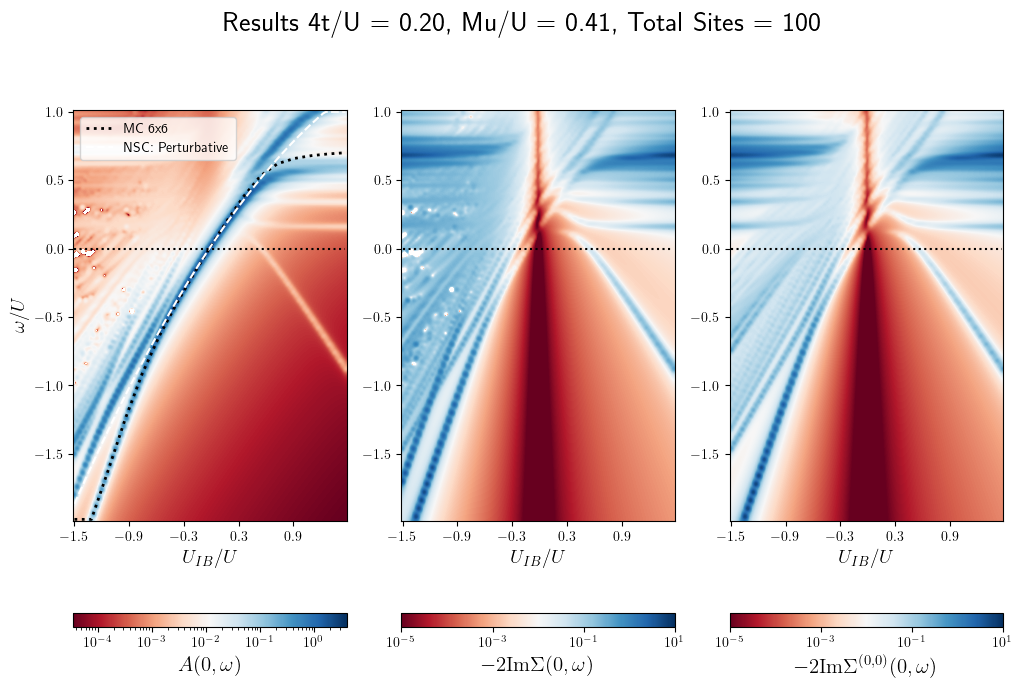

In [614]:
from scipy.interpolate import interp1d

plt.rcParams['text.usetex'] = True

# Rotate the image by -90 degrees
SpectralFuncs_rot = np.rot90(SpectralFuncs, 1)
Sigma_rot = np.rot90(Sigma, 1)
Sigma00_rot = np.rot90(Sigma00, 1)


fig, (ax1, ax2, ax3) = plt.subplots(ncols = 3, figsize = (12,8))

# Create the plot
# Set the aspect ratio to the ratio of the number of x points to the number of y points
aspect_ratio = 1#'auto'#1
im1 = ax1.imshow(SpectralFuncs_rot, interpolation = 'bicubic', cmap='RdBu', aspect = aspect_ratio, norm=matplotlib.colors.LogNorm())
im2 = ax2.imshow(-2*np.imag(Sigma_rot), interpolation = 'bicubic',cmap='RdBu', aspect = aspect_ratio, norm=matplotlib.colors.LogNorm())
im3 = ax3.imshow(-2*np.imag(Sigma00_rot), interpolation = 'bicubic',cmap='RdBu', aspect = aspect_ratio,norm=matplotlib.colors.LogNorm())


# Select a subset of dJUs and en_vector for the ticks
num_xticks = 6
num_yticks = 7

xticks = np.linspace(0, SpectralFuncs_rot.shape[1], num_xticks, endpoint=True, dtype=int)
yticks = np.linspace(0, SpectralFuncs_rot.shape[0], num_yticks, endpoint=True, dtype=int)

xticklabels = np.round(np.linspace(min(UIBs), max(UIBs), num_xticks),2)
yticklabels = np.round(np.linspace(max(en_vector), min(en_vector), num_yticks), 2)

# Format the labels in LaTeX
xticklabels = [r'$\mathrm{{{}}}$'.format(label) for label in xticklabels]
yticklabels = [r'$\mathrm{{{}}}$'.format(label) for label in yticklabels]

ax1.set_xticks(xticks)
ax1.set_yticks(yticks)
ax2.set_xticks(xticks)
ax2.set_yticks(yticks)
ax3.set_xticks(xticks)
ax3.set_yticks(yticks)
ax1.set_xticklabels(xticklabels)
ax1.set_yticklabels(yticklabels)
ax2.set_xticklabels(xticklabels)
ax2.set_yticklabels(yticklabels)
ax3.set_xticklabels(xticklabels)
ax3.set_yticklabels(yticklabels)
ax1.set_xlabel(r'$U_{IB}/U$', fontsize=14)
ax2.set_xlabel(r'$U_{IB}/U$', fontsize=14)
ax3.set_xlabel(r'$U_{IB}/U$', fontsize=14)
ax1.set_ylabel(r'$\omega/U$', fontsize=14)

cb1 = plt.colorbar(im1,orientation="horizontal")
cb1.set_label(label="$A(0,\omega)$",size=15,weight='bold')
cb2 = plt.colorbar(im2,orientation="horizontal")
cb2.set_label(label = "$-2\mathrm{Im\Sigma(0,\omega)}$",size=15,weight='bold')
cb3 = plt.colorbar(im3,orientation="horizontal")
cb3.set_label(label = "$-2\mathrm{Im\Sigma^{(0,0)}(0,\omega)}$",size=15,weight='bold')
# im1.set_clim(0, 1)
im2.set_clim(1e-5, 1e1)
im3.set_clim(1e-5, 1e1)

idx = np.searchsorted(en_vector, 0, side="left") # find \omega = 0

# X, Y = np.meshgrid(UIBs, omega0s + omega1s + omega2s)
# ax2 = ax.twinx()
# Transform the y-coordinates of the plot to match the image coordinates
uibmatija = u_ib_np8by8
Eimpmatija = E_imp_np8by8
plot_x = np.interp(uibmatija, (uibmatija.min(), uibmatija.max()), (0, SpectralFuncs_rot.shape[1]-1))
plot_y = SpectralFuncs_rot.shape[0] - 1 - np.interp(Eimpmatija, (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))

# Another method to interpolate
# interp_func_x = interp1d((u_ib_np.min(), u_ib_np.max()), (0, SpectralFuncs_rot.shape[1]-1), kind='linear', fill_value="extrapolate")
# interp_func_y = interp1d((en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1), kind='linear', fill_value="extrapolate")

# # Use interpolation functions
# plot_x = interp_func_x(u_ib_np)
# plot_y = SpectralFuncs_rot.shape[0] - 1 - interp_func_y(E_imp_np)

# Overlay the plot on top of the imshow figure
fig.suptitle(f"Results 4t/U = {dJU:0.2f}, Mu/U = {muU:0.2f}, Total Sites = {M}", fontsize = 20)
ax1.plot(plot_x, plot_y, linestyle = ':', label='MC 6x6', color='black', linewidth=2)

plot_x = np.interp(UIBs, (UIBs.min(), UIBs.max()), (0, SpectralFuncs_rot.shape[1]-1))
plot_y = SpectralFuncs_rot.shape[0] - 1 - np.interp(omega0s + omega1s + omega2s, (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))
plot_non_T = SpectralFuncs_rot.shape[0] - 1 - np.interp(np.real(Sigma_rot[idx,:]), (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))
plot_0 = len(en_vector) - idx + np.zeros(len(plot_y))

# Overlay the plot on top of the imshow figure
fig.suptitle(f"Results 4t/U = {dJU:0.2f}, Mu/U = {muU:0.2f}, Total Sites = {M}", fontsize = 20)
ax1.plot(plot_x, plot_y, linestyle = '--', label='NSC:  Perturbative', color='white', linewidth=1.5)

#ax1.plot(plot_x, plot_non_T, linestyle = ':', label='NSC:  Ladder', color='white', linewidth=1.5)
ax1.plot(plot_x, plot_0, linestyle = ':', color='black', linewidth=1.5)
ax2.plot(plot_x, plot_0, linestyle = ':', color='black', linewidth=1.5)
ax3.plot(plot_x, plot_0, linestyle = ':', color='black', linewidth=1.5)
#ax2.plot(plot_x, plot_y, linestyle = '--', label='Perturbative - Rayl. Schr.', color='white', linewidth=1.5)

ax1.legend()

plt.show()

<>:44: SyntaxWarning: invalid escape sequence '\o'
<>:44: SyntaxWarning: invalid escape sequence '\o'
/var/folders/ss/8jmv74q91hx88tdtr0hdx12c0000gn/T/ipykernel_8035/3624423280.py:44: SyntaxWarning: invalid escape sequence '\o'
  cb1.set_label(label="$A(0,\omega)$",size=15,weight='bold')


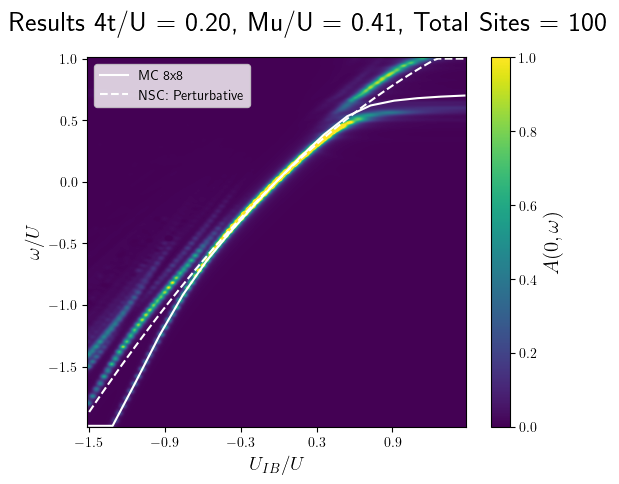

In [622]:
from scipy.interpolate import interp1d

plt.rcParams['text.usetex'] = True

# Rotate the image by -90 degrees
SpectralFuncs_rot = np.rot90(SpectralFuncs, 1)
Sigma_rot = np.rot90(Sigma, 1)
Sigma00_rot = np.rot90(Sigma00, 1)


fig, ax1 = plt.subplots( )

# Create the plot
# Set the aspect ratio to the ratio of the number of x points to the number of y points
aspect_ratio = 0.65#'auto'#1
im1 = ax1.imshow(SpectralFuncs_rot, interpolation = 'bicubic', aspect = aspect_ratio)#, norm=matplotlib.colors.LogNorm())


# Select a subset of dJUs and en_vector for the ticks
num_xticks = 6
num_yticks = 7

xticks = np.linspace(0, SpectralFuncs_rot.shape[1], num_xticks, endpoint=True, dtype=int)
yticks = np.linspace(0, SpectralFuncs_rot.shape[0], num_yticks, endpoint=True, dtype=int)

xticklabels = np.round(np.linspace(min(UIBs), max(UIBs), num_xticks),2)
yticklabels = np.round(np.linspace(max(en_vector), min(en_vector), num_yticks), 2)

# Format the labels in LaTeX
xticklabels = [r'$\mathrm{{{}}}$'.format(label) for label in xticklabels]
yticklabels = [r'$\mathrm{{{}}}$'.format(label) for label in yticklabels]

ax1.set_xticks(xticks)
ax1.set_yticks(yticks)

ax1.set_xticklabels(xticklabels)
ax1.set_yticklabels(yticklabels)

ax1.set_xlabel(r'$U_{IB}/U$', fontsize=14)

ax1.set_ylabel(r'$\omega/U$', fontsize=14)

cb1 = plt.colorbar(im1)
cb1.set_label(label="$A(0,\omega)$",size=15,weight='bold')

im1.set_clim(0, 1)

idx = np.searchsorted(en_vector, 0, side="left") # find \omega = 0

# X, Y = np.meshgrid(UIBs, omega0s + omega1s + omega2s)
# ax2 = ax.twinx()
# Transform the y-coordinates of the plot to match the image coordinates
plot_x = np.interp(uibmatija, (uibmatija.min(), uibmatija.max()), (0, SpectralFuncs_rot.shape[1]-1))
plot_y_matija = SpectralFuncs_rot.shape[0] - 1 - np.interp(Eimpmatija, (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))

# # Another method to interpolate
# interp_func_x = interp1d((uibmatija.min(), uibmatija.max()), (0, SpectralFuncs_rot.shape[1]-1), kind='linear', fill_value="extrapolate")

# interp_func_y = interp1d((en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1), kind='linear', fill_value="extrapolate")

# # Use interpolation functions
# plot_x = interp_func_x(uibmatija)
# plot_y = SpectralFuncs_rot.shape[0] - 1 - interp_func_y(Eimpmatija)
# plot_y[plot_y >149] = 149

# Overlay the plot on top of the imshow figure
fig.suptitle(f"Results 4t/U = {dJU:0.2f}, Mu/U = {muU:0.2f}, Total Sites = {M}", fontsize = 12)
ax1.plot(plot_x, plot_y_matija, label='MC 8x8', color='white', linewidth=1.5)

plot_x = np.interp(UIBs, (UIBs.min(), UIBs.max()), (0, SpectralFuncs_rot.shape[1]-1))
plot_y = SpectralFuncs_rot.shape[0] - 1 - np.interp(omega0s + omega1s + omega2s, (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))
plot_non_T = SpectralFuncs_rot.shape[0] - 1 - np.interp(np.real(Sigma_rot[idx,:]), (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))
plot_0 = len(en_vector) - idx + np.zeros(len(plot_y))

# Overlay the plot on top of the imshow figure
fig.suptitle(f"Results 4t/U = {dJU:0.2f}, Mu/U = {muU:0.2f}, Total Sites = {M}", fontsize = 20)
ax1.plot(plot_x, plot_y, linestyle = '--', label='NSC:  Perturbative', color='white', linewidth=1.5)

#ax1.plot(plot_x, plot_non_T, linestyle = ':', label='NSC:  Ladder', color='white', linewidth=1.5)
# ax1.plot(plot_x, plot_0, color='black', linewidth=1.5)
# ax1.set_ylim(-1, 1 - SpectralFuncs_rot.shape[0])

#ax2.plot(plot_x, plot_y, linestyle = '--', label='Perturbative - Rayl. Schr.', color='white', linewidth=1.5)

ax1.legend()

plt.show()

-0.8939393939393939


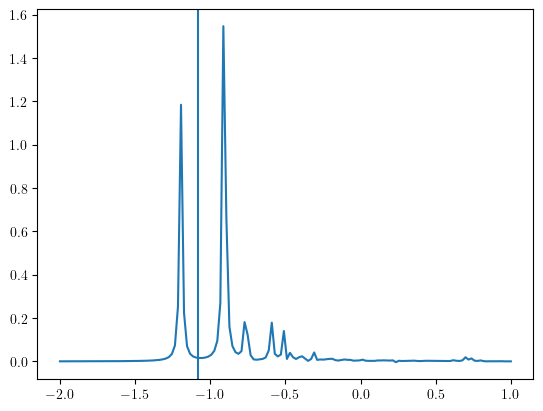

In [623]:
ind = 20
print(UIBs[ind])
plt.plot(en_vector, SpectralFuncs[ind,:])
plt.axvline(x =interpolated_values[ind])

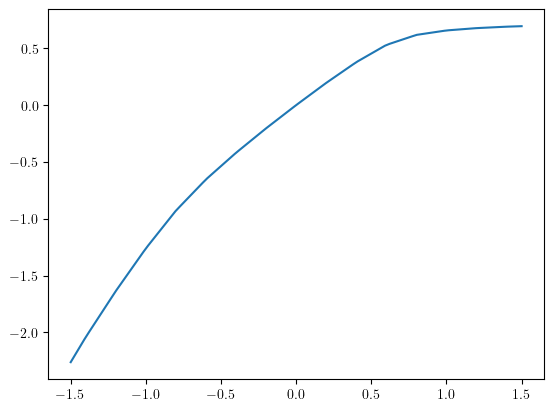

In [608]:
from scipy.interpolate import interp1d

# Create an interpolation function that allows extrapolation
f = interp1d(uibmatija, Eimpmatija, fill_value="extrapolate", bounds_error=False)

# Calculate the interpolated function at UIBs
interpolated_values = f(UIBs)

# Plot the interpolated values
plt.plot(UIBs, interpolated_values, label="Interpolated values")

In [1]:
import numpy as np

# Initialize an empty list to store the indices of the maxima
max_indices = []
threshold = 0.
# Put the spectral function in a new array with 0 values for energies above the interpolated values
spectralFuncs2 = np.zeros(SpectralFuncs.shape)
for i in range(SpectralFuncs.shape[0]):
    for j in range(SpectralFuncs.shape[1]):
        spectralFuncs2[i, j] = SpectralFuncs[i, j]
        if (en_vector[j] > interpolated_values[i] + 0.1 ):
            spectralFuncs2[i, j] = 0

# Loop over each row in the Spectral function
for i in range(SpectralFuncs.shape[0]):
    # Find the index of the first maximum that is higher than 0.4
    row = spectralFuncs2[i, :]
    max_index = np.argmax(row)
    
    # If the maximum is higher than 0.4, add the index to the list
    # if row[max_index] > threshold:
    max_indices.append(en_vector[max_index])
    # else:
    #     # If there is no maximum higher than 0.4, add a placeholder (e.g., None)
    #     max_indices.append(None)

# Convert the list to a numpy array
max_indices = np.array(max_indices)
start = 7
end = 99
UIBs_cond = UIBs[start:end]
max_indices_cond = max_indices[start:end]
plt.scatter(UIBs_cond, max_indices_cond- UIBs_cond)

plt.plot(uibmatija, Eimpmatija - uibmatija)
plt.xlabel('U_IB/U')


NameError: name 'SpectralFuncs' is not defined

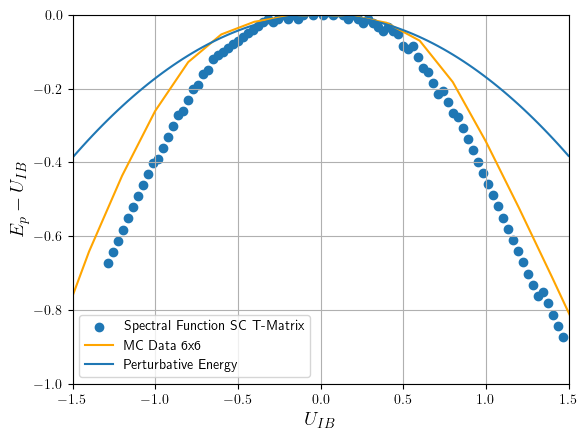

In [610]:
from scipy.optimize import curve_fit
import numpy as np

import csv
import matplotlib.pyplot as plt



# u_ib = []
# E_imp = []
# # Convert string data to float
# u_ib_cond = np.zeros(len(data['u_ib']))
# for i in np.arange(0,len(data['u_ib'])):
#     u_ib.append(float(data['u_ib'][i]))
#     E_imp.append(float(data['E_p'][i]))

# u_ib_np = np.array(u_ib).T
# E_imp_np = np.array(E_imp)


# Define the fit function
def fit_func(x, alpha):
    return alpha * x**2

x = UIBs_cond
y = max_indices_cond - UIBs_cond #+np.min(np.abs(max_indices_cond - UIBs_cond))

# Fit the data to the fit function
popt, pcov = curve_fit(fit_func, x, y)

# Get the fitted alpha
alpha = popt[0]

# Generate x values for the fitted function
x_fit = np.linspace(-1.5, 1.5, 100)

# Generate y values for the fitted function
y_fit = fit_func(x_fit, alpha)

# Plot the original data
plt.scatter(x, y, label='Spectral Function SC T-Matrix')

# Plot the fitted function
# plt.plot(x_fit, y_fit, color='red', label='Fit: $y = \\alpha x^2$')
plt.plot(uibmatija , Eimpmatija - uibmatija, label='MC Data 6x6', color='orange')
plt.plot(UIBs, omega0s + omega1s + omega2s - UIBs, label='Perturbative Energy')
# Add a legend
plt.ylabel(r'$E_p - U_{IB}$', fontsize=14)
plt.xlabel(r'$U_{IB}$', fontsize=14)
plt.xlim(-1.5, 1.5)
plt.ylim(-1.0, 0)
plt.grid()
plt.legend()

# Show the plot
plt.show()

In [611]:
## Save the figure 
#filename = f'../figs/Spectral_Line_UIB_Scan/dJU_{dJU}_Mu_{muU:.2f}_M_{grid.M}_N_{N}_num_en_{num_en}_num_UIB_{num_UIB}.pdf'
filename = f'../figs/self_consistent_t/ladder_ground/dJU_{dJU}_Mu_{muU:.2f}_M_{grid.M}_N_{N}_num_en_{num_en}_num_UIB_{num_UIB}_eta_{eta}_cutoff_{cutoff}_alt.pdf'
fig.savefig(filename, dpi=300, bbox_inches='tight')



In [612]:
# Save the data

# Code to save results for different UIBs
#filename = f'./data/Spectral_Line_UIB_Scan/dJU_{dJU}_Mu_{muU:.2f}_M_{grid.M}_N_{N}_num_en_{num_en}_num_UIB_{num_UIB}.hdf5'
filename = f'./data/self_consistent_t/ladder_ground/dJU_{dJU}_Mu_{muU:.2f}_M_{grid.M}_N_{N}_num_en_{num_en}_num_UIB_{num_UIB}_eta_{eta}_cutoff_{cutoff}_alt.hdf5'


with h5py.File(filename, 'w') as f:
    f.create_dataset('UIBs', data=UIBs)
    f.create_dataset('en_vector', data=en_vector)
    f.create_dataset('omega0s', data=omega0s)
    f.create_dataset('omega1s', data=omega1s)
    f.create_dataset('omega2s', data=omega2s)
    for i, UIB in enumerate(UIBs):
    # Create a group for this dJU value
        group = f.create_group(f'UIB_{UIB}')

        # Store the arrays in this group
        group.create_dataset('T11', data=T11[i, :])
        group.create_dataset('T12', data=T12[i, :])
        group.create_dataset('T21', data=T21[i, :])
        group.create_dataset('T22', data=T22[i, :])
        group.create_dataset('T22_SE', data=T22_F[i, :])
        group.create_dataset('SE_SI', data=SE_SI[i, :])
    

    # Create attributes for your parameters
    f.attrs['dJU'] = dJU
    f.attrs['muU'] = muU
    f.attrs['Lx'] = grid.Lx
    f.attrs['Ly'] = grid.Ly
    f.attrs['N'] = N


    UIBs = f['UIBs'][:]
    en_vector = f['en_vector'][:]
    omega0s = f['omega0s'][:]
    omega1s = f['omega1s'][:]
    omega2s = f['omega2s'][:]

    T11 = []
    T12 = []
    T21 = []
    T22 = []
    T22_SE = []
    SE_SI = []

    for count, UIB in enumerate(UIBs):
        group = f[f'UIB_{UIB}']
        T11.append(group['T11'][:])
        T12.append(group['T12'][:])
        T21.append(group['T21'][:])
        T22.append(group['T22'][:])
        T22_SE.append(group['T22_SE'][:])
        SE_SI.append(group['SE_SI'][:])

FileNotFoundError: [Errno 2] Unable to create file (unable to open file: name = './data/self_consistent_t/ladder_ground/dJU_0.2_Mu_0.41_M_100_N_7_num_en_150_num_UIB_100_eta_0.1_cutoff_3_alt.hdf5', errno = 2, error message = 'No such file or directory', flags = 13, o_flags = 602)